# BigQuery (Public) — Docker + Service Account JSON 🔐

## Objective
Query the public BigQuery table:

- **Project**: `edhec-01`
- **Dataset**: `luxurydata2502`
- **Table**: `price-monitoring-2022`

…and retrieve rows for any **brand** using **Python** inside **Docker**.

---

## Why credentials if the table is public? 🤔

💡 BigQuery API calls are **never anonymous**.  
Public data means *no special table permissions* are required, but an identity is still required to run **query jobs**.

✅ Authentication method used here: **Service Account JSON key** mounted into the container (only).

---

### BigQuery UI (reference)
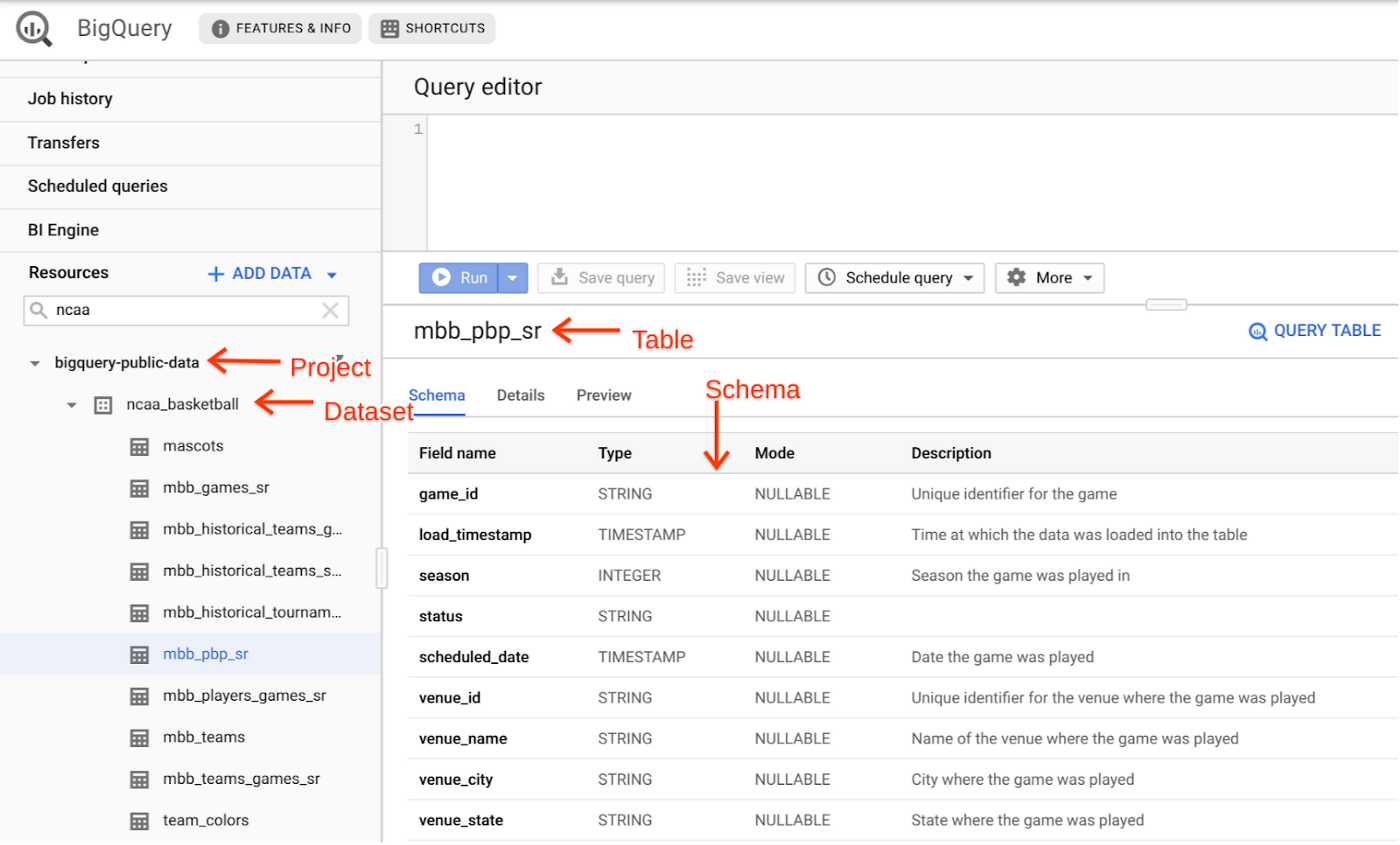


---

## 1) Create a Service Account + JSON Key (Console) 🧩

### 1.1 Navigate
- **Google Cloud Console** → **IAM & Admin** → **Service Accounts**
- Select the correct project (top bar)

### 1.2 Create the service account
Example:
- **Name**: `bq-public-reader`

### 1.3 Minimal permissions (project-level)
To execute queries, the service account must be allowed to create BigQuery jobs:

✅ **BigQuery Job User** (`roles/bigquery.jobUser`)

> If later you create datasets/tables, add **BigQuery User** (`roles/bigquery.user`).

### 1.4 Create a JSON key
Open the service account → **Keys** → **Add key** → **Create new key** → **JSON**.

**Where to click (Keys → Add key):**

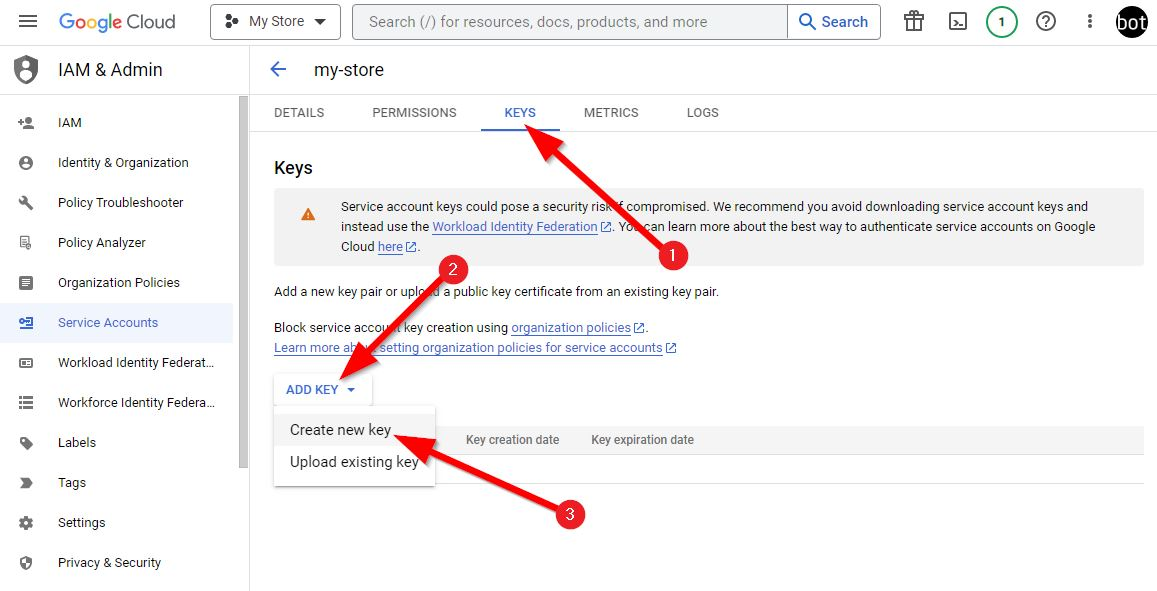

**Choose JSON:**

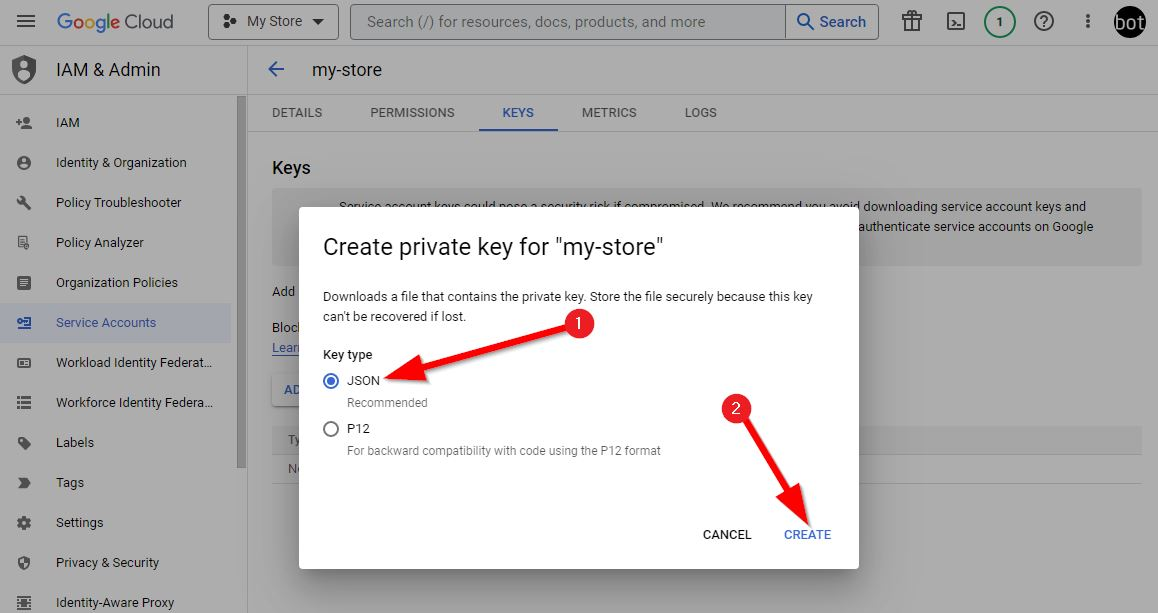

✅ Save the downloaded file locally as:

```
./secrets/bq-sa.json
```

🚫 Never commit this file to Git.


---

## 2) Docker repository files — what they do 📦

This repo is intentionally minimal:

```
bigquery-public-docker/
├─ Dockerfile
├─ requirements.txt
├─ Makefile
├─ docker-compose.yml
├─ .gitignore
└─ notebooks/
   └─ Day_01_BigQuery_Public_Docker_ServiceAccount.ipynb
```

### `Dockerfile`
Defines the container image:
- starts from `python:3.11-slim`
- installs OS essentials (`ca-certificates`, `curl`)
- installs Python dependencies
- starts **JupyterLab** on port **8888**

### `requirements.txt`
Python packages installed inside the image:
- `google-cloud-bigquery`
- `pandas`, `pyarrow`
- `jupyterlab`, `ipykernel`

### `Makefile`
Short commands:
- `make build`
- `make run-sa` (mounts the JSON key and sets env vars)

### `docker-compose.yml` (optional)
Same idea as `docker run`, described declaratively.

### `.gitignore`
Prevents committing:
- `secrets/` and `*.json` keys
- `*.csv` exports
- notebook checkpoints


---

## 3) Put the key in the repo (local only) ✅

Create the folder and place the key at:

```
secrets/bq-sa.json
```

💡 This path is expected by the `Makefile` and `docker-compose.yml`.


In [ ]:
# from the repo root
mkdir -p secrets
# move the downloaded JSON here:
# mv ~/Downloads/<your-key>.json secrets/bq-sa.json

ls -lh secrets/bq-sa.json


---

## 4) Build & run the container 🐳

### 4.1 Build


In [ ]:
make build

### 4.2 Run (service account only)
This mounts the key into the container and sets:
- `GOOGLE_APPLICATION_CREDENTIALS=/secrets/bq-sa.json`


In [ ]:
make run-sa

When the container starts, JupyterLab prints a URL like:

```text
http://127.0.0.1:8888/lab?token=...
```

Open it in the browser.


---

## 5) Verify credentials inside Docker (sanity checks) 🧪

Run these commands in a Jupyter terminal **inside the container**:


In [ ]:
ls -lh /secrets/bq-sa.json
echo $GOOGLE_APPLICATION_CREDENTIALS
python -c "import os; print('GOOGLE_APPLICATION_CREDENTIALS=', os.getenv('GOOGLE_APPLICATION_CREDENTIALS'))"


---

## 6) Query the public table with Python 🧠

### 6.1 Setup


In [ ]:
from google.cloud import bigquery

PROJECT_ID = "edhec-01"
DATASET_ID = "luxurydata2502"
TABLE_ID   = "price-monitoring-2022"
FULL_TABLE = f"`{PROJECT_ID}.{DATASET_ID}.{TABLE_ID}`"

# The client reads the service account key from GOOGLE_APPLICATION_CREDENTIALS
client = bigquery.Client(project=PROJECT_ID)


### 6.2 Smoke test (LIMIT 10)


In [ ]:
sql = f"""
SELECT *
FROM {FULL_TABLE}
LIMIT 10
"""

df = client.query(sql).to_dataframe()
df


---

## 7) Discover available brands 🏷️

This avoids guessing the exact `brand` string.


In [ ]:
sql = f"""
SELECT brand, COUNT(*) AS n
FROM `edhec-01.luxurydata2502.price-monitoring-2022`
GROUP BY brand
ORDER BY n DESC
LIMIT 50
"""

brands_df = client.query(sql).to_dataframe()
brands_df


---

## 8) Query by brand (parameterized query) ✅

💡 Parameterized queries are cleaner and safer than string concatenation.


In [ ]:
import pandas as pd

def fetch_by_brand(brand: str, limit: int = 2000) -> pd.DataFrame:
    sql = f"""
    SELECT
      uid, brand, url, price, currency, image_url, collection,
      reference_code, life_span_date, life_span,
      price_before, price_difference, price_percent_change, price_changed
    FROM `edhec-01.luxurydata2502.price-monitoring-2022`
    WHERE brand = @brand
    ORDER BY life_span_date DESC
    LIMIT @limit
    """

    job_config = bigquery.QueryJobConfig(
        query_parameters=[
            bigquery.ScalarQueryParameter("brand", "STRING", brand),
            bigquery.ScalarQueryParameter("limit", "INT64", limit),
        ]
    )

    return client.query(sql, job_config=job_config).to_dataframe()

df_brand = fetch_by_brand("Cartier", limit=50)
df_brand.head()


---

## 9) Export a brand extract (CSV) 📤


In [ ]:
output_path = "price_monitoring_brand_extract.csv"
df_brand.to_csv(output_path, index=False)
output_path


---

## 10) Troubleshooting 🔧

### `403: bigquery.jobs.create`
The service account is missing the project role:
- ✅ **BigQuery Job User** (`roles/bigquery.jobUser`)

### `FileNotFoundError: /secrets/bq-sa.json`
The key is not mounted correctly.
- verify: `secrets/bq-sa.json` exists on host
- verify: the mount exists in `Makefile` / `docker-compose.yml`
